# Lunar Lander Reinforcement Learning Agent using PPO

This notebook trains a reinforcement learning agent using Proximal Policy Optimization (PPO) to solve the LunarLander-v3 environment from Gymnasium.

Installing dependencies

In [10]:
!pip install stable-baselines3[extra] gymnasium[box2d]

Imports

In [11]:
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
import matplotlib.pyplot as plt
import numpy as np
import imageio

Reward Callback:

In [12]:
class RewardCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self.current_rewards = 0

    def _on_step(self):
        self.current_rewards += self.locals["rewards"][0]
        if self.locals["dones"][0]:
            self.episode_rewards.append(self.current_rewards)
            self.current_rewards = 0
        return True

Training

In [13]:
env = Monitor(gym.make("LunarLander-v3"))

model = PPO(
    "MlpPolicy",
    env,
    verbose=1,
    seed=42
)

cb = RewardCallback()

model.learn(total_timesteps=1_000_000, callback=cb)

model.save("ppo_lunarlander")

Streaming output truncated to the last 5000 lines.
|    value_loss           | 80.3         |
------------------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 421         |
|    ep_rew_mean          | 95.6        |
| time/                   |             |
|    fps                  | 673         |
|    iterations           | 252         |
|    time_elapsed         | 766         |
|    total_timesteps      | 516096      |
| train/                  |             |
|    approx_kl            | 0.005943062 |
|    clip_fraction        | 0.0344      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.594      |
|    explained_variance   | 0.76        |
|    learning_rate        | 0.0003      |
|    loss                 | 137         |
|    n_updates            | 2510        |
|    policy_gradient_loss | -0.00275    |
|    value_loss           | 85.6        |
-----------------------

Evaluation

In [14]:
mean_reward, std_reward = evaluate_policy(
    model,
    env,
    n_eval_episodes=10,
    deterministic=True
)

print(f"Mean reward: {mean_reward:.2f} +/- {std_reward:.2f}")

Mean reward: 217.60 +/- 13.77


Plotting the reward curve

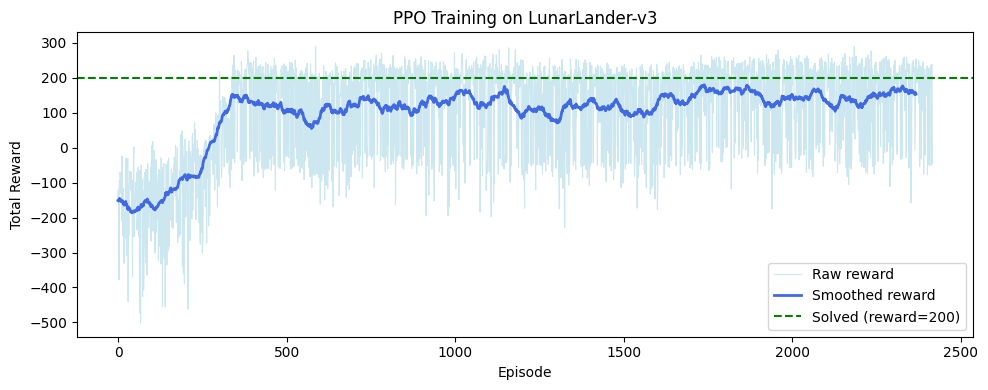

In [15]:
def smooth(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(cb.episode_rewards, color='lightblue', linewidth=0.8, alpha=0.6, label='Raw reward')
plt.plot(smooth(cb.episode_rewards), color='royalblue', linewidth=2, label='Smoothed reward')
plt.axhline(y=200, color='green', linestyle='--', label='Solved (reward=200)')
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("PPO Training on LunarLander-v3")
plt.legend()
plt.tight_layout()
plt.savefig("reward_curve.png", dpi=150)
plt.show()

Saving the GIF

In [16]:
env_render = gym.make("LunarLander-v3", render_mode="rgb_array")
model_loaded = PPO.load("ppo_lunarlander")

frames = []
obs, _ = env_render.reset()

for _ in range(600):
    action, _ = model_loaded.predict(obs, deterministic=True)
    obs, reward, done, truncated, _ = env_render.step(action)
    frames.append(env_render.render())

    if done or truncated:
        break

imageio.mimsave("trained_agent.gif", frames, fps=30)
print("GIF saved!")

GIF saved!


Downloading the files

In [17]:
from google.colab import files
files.download("trained_agent.gif")
files.download("reward_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Agent Behaviour without PPO

In [18]:
import gymnasium as gym
import numpy as np
import imageio

env_random = gym.make("LunarLander-v3", render_mode="rgb_array")

frames = []
obs, _ = env_random.reset()

for _ in range(600):
    action = env_random.action_space.sample()  # RANDOM ACTION
    obs, reward, done, truncated, _ = env_random.step(action)

    frames.append(env_random.render())

    if done or truncated:
        break

env_random.close()

imageio.mimsave("random_agent.gif", frames, fps=30)

print("Random agent GIF saved!")

files.download("random_agent.gif")

Random agent GIF saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>